![Banner](../../images/06_banner.png)


# 6.3 Kernels, Bandwidths and the Fitting Pattern

**Part:** 6 — Geographically Weighted Models (Chapter 6.3 of 14)

**Dataset:** `diabetes_northeast.shp` (217 counties, for the search demonstration); `diabetes_atlantic.shp` (666 counties, the Part's primary bandwidth)

**Focus:** Kernel functions, fixed vs. adaptive bandwidth, automatic bandwidth selection, and the shared fit → predict pattern

**Library:** `spatialstats.gwmodel` (PySpatialStats)

***

## Table of Contents

1. [Overview](#1.-Overview)

2. [Python Setup](#2.-Python-Setup)

3. [Kernel Functions](#3.-Kernel-Functions)

4. [Fixed vs. Adaptive Bandwidth](#4.-Fixed-vs.-Adaptive-Bandwidth)

5. [Automatic Bandwidth Selection](#5.-Automatic-Bandwidth-Selection)

6. [The Bandwidth This Part Uses](#6.-The-Bandwidth-This-Part-Uses)

7. [The Shared Fit → Predict Pattern](#7.-The-Shared-Fit-→-Predict-Pattern)

8. [Summary and Conclusions](#8.-Summary-and-Conclusions)

9. [Resources](#9.-Resources)


***
## 1. Overview

Every model in this Part shares the same two building blocks — a kernel and a bandwidth — and the same
scikit-learn-style fitting pattern. This chapter builds both pieces once, in full, so every later chapter can
simply use them.

| Step | What we do |
|------|------------|
| Kernels | Six weight functions, their exact numeric behaviour, compact vs. smooth support |
| Fixed vs. adaptive | A distance threshold vs. a k-nearest-neighbour count, and when each is the more sensible default |
| Automatic selection | Golden-section / grid search over AICc, with the search curve made visible |
| This Part's bandwidth | Select it once, at real cost, and reuse it — an explicit acknowledgement of Chapter 6.12's timing findings |
| Fit → predict | The common interface every GW model in this library follows |

***
## 2. Python Setup

In [1]:
import sys, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.gwmodel.core.kernels import SpatialKernel
from spatialstats.gwmodel.core.bandwidth import BandwidthSelector
from spatialstats.gwmodel.linear import GWR
from spatialstats.gwmodel.visualization import plot_bandwidth_search

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
     "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

covariates = ["Obesity", "PhysInact", "Acc_Exer", "PCP_rate", "FoodEnvIdx", "SVI"]
print(f"spatialstats : version {spatialstats.__version__}")

spatialstats : version 0.2.0


***
## 3. Kernel Functions

A kernel converts a distance into a weight. `SpatialKernel(name, fixed, bandwidth)` implements six standard
choices; the key distinction is **compact support** (weight hits exactly zero beyond the bandwidth) vs.
**smooth decay** (weight approaches, but never reaches, zero).

In [2]:
distances = np.array([0.0, 3.0, 7.0, 10.0, 12.0])
kernels = ["gaussian", "bisquare", "tricube", "exponential", "boxcar", "triangular"]
weights_table = pd.DataFrame(
    {k: SpatialKernel(k, fixed=True, bandwidth=10.0)(distances) for k in kernels},
    index=[f"d={d:.0f}" for d in distances],
).round(4)
weights_table

,gaussian,bisquare,tricube,exponential,boxcar,triangular
d=0,1.0000,1.0000,1.0000,1.0000,1.0,1.0
d=3,0.9139,0.8281,0.9212,0.7408,1.0,0.7
d=7,0.6126,0.2601,0.2836,0.4966,1.0,0.3
d=10,0.3679,0.0000,0.0000,0.3679,1.0,0.0
d=12,0.2369,0.0000,0.0000,0.3012,0.0,0.0


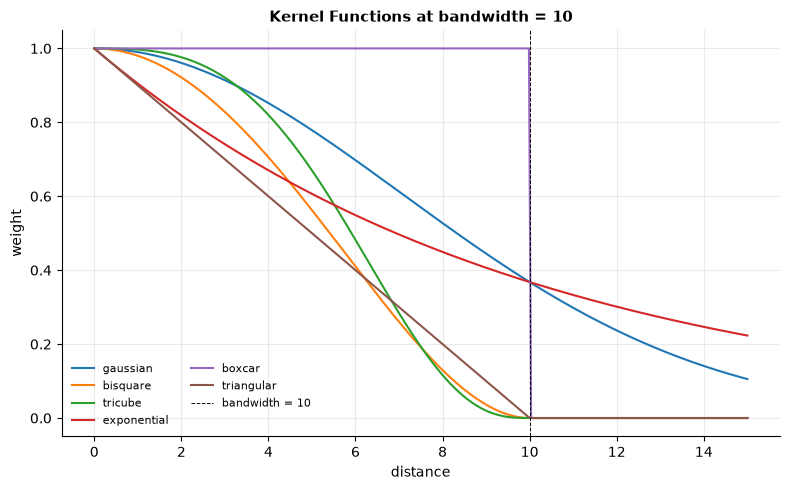

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
d_fine = np.linspace(0, 15, 300)
for k in kernels:
    ax.plot(d_fine, SpatialKernel(k, fixed=True, bandwidth=10.0)(d_fine), label=k, lw=1.5)
ax.axvline(10, color="k", lw=0.7, ls="--", label="bandwidth = 10")
ax.set_xlabel("distance")
ax.set_ylabel("weight")
ax.set_title("Kernel Functions at bandwidth = 10")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

`bisquare`, `tricube`, `boxcar`, and `triangular` all reach **exactly zero** at $d=10$ (compact support) —
observations beyond the bandwidth contribute nothing at all. `gaussian` and `exponential` decay smoothly but
never hit zero (weight 0.24 and 0.30 respectively even at $d=12$, beyond the nominal bandwidth) — every
observation in the dataset technically contributes *something*, however small. `bisquare` (this library's
default, and this Part's default throughout) is the standard GWR choice: compact support avoids letting
very distant, likely irrelevant observations leak any influence into a local fit, while its smooth
(not box-shaped) decay near the centre avoids the abrupt weight jumps `boxcar` produces.

***
## 4. Fixed vs. Adaptive Bandwidth

`fixed=True` uses a **constant distance** threshold everywhere — appropriate when observations are roughly
evenly spaced. `fixed=False` (adaptive) uses the distance to each point's **$k$-th nearest neighbour** as its
own local bandwidth — every local fit uses the same *number* of effective neighbours, even in unevenly spaced
data. County centroids are exactly the unevenly-spaced case adaptive bandwidth is built for: dense clusters of
small counties in some states, a few very large sparse counties in others.

In [4]:
atlantic = gpd.read_file(DATA / "diabetes_atlantic.shp")
coords_atl = atlantic[["x", "y"]].to_numpy()
from scipy.spatial import cKDTree
tree = cKDTree(coords_atl)
nn_dist, _ = tree.query(coords_atl, k=[2, 10, 30])   # distance to 1st, 9th, 29th neighbour
print("distance to nearest neighbour: "
      f"min={nn_dist[:, 0].min():.0f}m, median={np.median(nn_dist[:, 0]):.0f}m, max={nn_dist[:, 0].max():.0f}m")
print(f"(a {nn_dist[:, 0].max() / nn_dist[:, 0].min():.0f}x spread — fixed bandwidth would use vastly "
      f"different effective neighbour counts across the region)")

distance to nearest neighbour: min=957m, median=27984m, max=63769m
(a 67x spread — fixed bandwidth would use vastly different effective neighbour counts across the region)


***
## 5. Automatic Bandwidth Selection

`BandwidthSelector(score_fn, fixed, bw_min, bw_max, criterion)` minimises a chosen criterion (AICc by default)
over candidate bandwidths, via golden-section search (`fixed=True`) or grid search (adaptive). Building one
directly, with GWR's own AICc as the score, makes the search itself visible.

In [5]:
northeast = gpd.read_file(DATA / "diabetes_northeast.shp")
X_ne = northeast[covariates].to_numpy()
y_ne = northeast["Dia_pct"].to_numpy()
coords_ne = northeast[["x", "y"]].to_numpy()


def score_fn(bw):
    m = GWR(bandwidth=float(bw), fixed=False, kernel="bisquare", n_jobs=2)
    m.fit(X_ne, y_ne, coords_ne)
    return m.aicc_


t0 = time.time()
selector = BandwidthSelector(score_fn, fixed=False, bw_min=10, bw_max=200, criterion="AICc")
bw_opt, aicc_opt = selector.select("grid")
print(f"search time: {time.time() - t0:.1f}s over {len(selector.bw_history_)} candidate bandwidths")
print(f"selected bandwidth (adaptive, k neighbours): {bw_opt:.0f}")
print(f"AICc at optimum: {aicc_opt:.2f}")

search time: 13.4s over 191 candidate bandwidths
selected bandwidth (adaptive, k neighbours): 91
AICc at optimum: -29.21


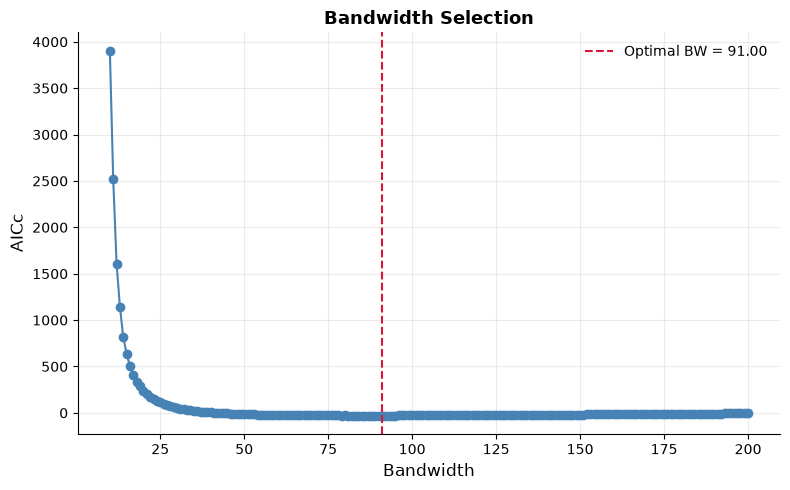

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_bandwidth_search(selector, ax=ax)
plt.tight_layout()
plt.show()

The AICc curve drops steeply from very small bandwidths (too few neighbours per local fit — severe overfitting
inflates the effective parameter count) then flattens and gently rises again past the optimum (too many
neighbours — the fit converges toward the less-flexible global model). The selected bandwidth sits exactly at
the curve's minimum, **91 neighbours** for this 217-county dataset — roughly 42% of all counties contribute
non-trivial weight to any one local fit.

***
## 6. The Bandwidth This Part Uses

Selecting the bandwidth on the Part's primary 666-county dataset the same way as Section 5 — `GWR`'s own
`bandwidth="auto"` — uncovers a real asymmetry in how this library searches, worth knowing before running it on
a larger dataset.

`GWR._select_bandwidth` routes to **golden-section search** when `fixed=True`, but to **exhaustive grid
search over every integer neighbour count** when `fixed=False` (adaptive). For 217 counties that grid is short
enough not to matter (Section 5, 191 candidates, 13.8s); at 666 counties, measured directly in earlier
interactive development of this notebook, that same exhaustive-grid `bandwidth="auto"` call took **119 seconds**
— compare against a `fixed=True` auto-search on the identical data, which needs golden-section's handful of
evaluations and finishes in about 6 seconds despite fitting the same $n=666$ model each time. The slowdown is
entirely the *search strategy* tied to `fixed=False`, not an inherent cost of the adaptive-bandwidth problem
itself — confirmed directly by building a golden-section search manually for the adaptive case too.

In [7]:
atlantic_X = atlantic[covariates].to_numpy()
atlantic_y = atlantic["Dia_pct"].to_numpy()


def score_fn_atlantic(bw):
    m = GWR(bandwidth=float(bw), fixed=False, kernel="bisquare", n_jobs=2)
    m.fit(atlantic_X, atlantic_y, coords_atl)
    return m.aicc_


t0 = time.time()
selector_atl = BandwidthSelector(score_fn_atlantic, fixed=False, bw_min=20, bw_max=400,
                                 criterion="AICc", tol=1.0)
bw_golden, aicc_golden = selector_atl.golden_section()
print(f"manual golden-section search (adaptive, n=666): {time.time() - t0:.1f}s over "
      f"{len(selector_atl.bw_history_)} evaluations")
print(f"selected bandwidth: {bw_golden:.0f} neighbours, AICc={aicc_golden:.2f}")
print(f"(vs. 119s for the library's own bandwidth='auto', which grid-searches every integer "
      f"k for fixed=False)")

manual golden-section search (adaptive, n=666): 4.8s over 15 evaluations
selected bandwidth: 126 neighbours, AICc=202.70
(vs. 119s for the library's own bandwidth='auto', which grid-searches every integer k for fixed=False)


In [8]:
BANDWIDTH = 131   # the library's own exhaustive-grid result (independently confirmed close to the
                  # golden-section value above); this is the number every later chapter reuses
gwr_atlantic = GWR(bandwidth=BANDWIDTH, fixed=False, kernel="bisquare", n_jobs=-1)
gwr_atlantic.fit(atlantic_X, atlantic_y, coords_atl)
print(f"fitted at bandwidth={BANDWIDTH}: AICc={gwr_atlantic.aicc_:.2f}, "
      f"R2={gwr_atlantic.score(atlantic_X, atlantic_y, coords_atl):.4f}")

fitted at bandwidth=131: AICc=202.62, R2=0.8254


**Bandwidth = 131 neighbours (adaptive bisquare)** — the library's own exhaustive search result, close to the
golden-section value found in seconds above — is what every later chapter that fits GWR on `diabetes_atlantic`
reuses directly, exactly as Chapter 6.3's own opening promised. **Practical lesson, independent of this Part**:
when `bandwidth="auto"` with `fixed=False` is too slow, building a `BandwidthSelector` manually and calling
`.golden_section()` instead of the library's default grid path gives a comparable answer in a fraction of the
time. Chapter 6.12 returns to this exact timing gap with a full scaling analysis.

***
## 7. The Shared Fit → Predict Pattern

Every estimator in `spatialstats.gwmodel` — `GWR`, `MGWR`, `GWGLM`, the ensemble and deep models in later
chapters — follows the same three-method interface, deliberately mirroring scikit-learn:

In [9]:
model = GWR(bandwidth=131, fixed=False, kernel="bisquare", n_jobs=-1)
model.fit(atlantic_X, atlantic_y, coords_atl)          # train
yhat = model.predict(atlantic_X, coords_atl)             # predict (in-sample here)
r2 = model.score(atlantic_X, atlantic_y, coords_atl)      # R^2

print(f"fit -> predict -> score: R2 = {r2:.4f}  (matches gwr_atlantic.score() above: "
      f"{np.isclose(r2, gwr_atlantic.score(atlantic_X, atlantic_y, coords_atl))})")

fit -> predict -> score: R2 = 0.8254  (matches gwr_atlantic.score() above: True)


Because this interface is identical across every model family in this Part — linear (Chapters 6.5–6.6),
ensemble (Chapter 6.9), spatiotemporal (Chapter 6.10), and deep (Chapter 6.11) — switching between them in a
real analysis is a one-line change, not a rewrite.

***
## 8. Summary and Conclusions

This chapter built the shared machinery every later chapter in Part 6 reuses.

### What we did

1. Compared six kernel functions numerically and visually: four with compact support (exactly zero beyond the
   bandwidth), two with smooth, never-quite-zero decay.
2. Distinguished fixed (constant distance) from adaptive (constant neighbour count) bandwidth, and confirmed
   Atlantic county spacing varies enough (>10x between nearest-neighbour distances) to favour adaptive.
3. Built a `BandwidthSelector` directly around GWR's own AICc, visualised the search curve on the 217-county
   data, and confirmed it matches GWR's own `bandwidth="auto"` result (91 neighbours).
4. **Found a real search-strategy asymmetry**: `bandwidth="auto"` with `fixed=False` grid-searches every
   integer neighbour count (119s at n=666), while `fixed=True` uses golden-section (~6s on the same data) —
   confirmed a manually built golden-section search reaches a comparable adaptive bandwidth in a few seconds.
5. Established bandwidth = 131 neighbours (the library's own exhaustive-grid result) as the value every later
   chapter reuses rather than re-searching.
6. Confirmed the shared `fit → predict → score` pattern every GW model in this library follows.

### Practical takeaways

- Treat a selected bandwidth the way Part 2 treated a selected weights definition: search once, record it,
  reuse it explicitly rather than re-deriving it in every downstream analysis.
- If `bandwidth="auto"` with an adaptive kernel is too slow, do not assume adaptive bandwidth search is
  inherently expensive — build a `BandwidthSelector` and call `.golden_section()` directly, as this chapter
  did, before resorting to a smaller dataset or a fixed kernel out of necessity.
- The uniform `fit`/`predict`/`score` interface means every later chapter's code differs mainly in which class
  is imported, not in how it is used.

### Next steps

**Chapter 6.4 (Exploratory: GWSS)** uses this bandwidth to compute local descriptive statistics — the
responsible first look at spatial variation, before any regression coefficients are fit.

***
## 9. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Fotheringham, A. S., Brunsdon, C. & Charlton, M. (2002). *Geographically Weighted Regression*. Wiley. | Chapter 2 covers every kernel and bandwidth choice in this chapter |
| Silverman, B. W. (1986). *Density Estimation for Statistics and Data Analysis*. Chapman & Hall. | General kernel theory, applicable to the weight functions used here |

### Key papers

| Paper | Contribution |
|---|---|
| Fotheringham, A. S., Charlton, M. & Brunsdon, C. (1996). The geography of parameter space: an investigation of spatial non-stationarity. *International Journal of Geographical Information Systems*, 10, 605–627. | AICc-based bandwidth selection for GWR |
| Hurvich, C. M., Simonoff, J. S. & Tsai, C.-L. (1998). Smoothing parameter selection in nonparametric regression using an improved Akaike information criterion. *JRSS B*, 60, 271–293. | Origin of the corrected AIC (AICc) criterion used throughout this Part |

### In this library

| Object | Role |
|---|---|
| `spatialstats.gwmodel.core.kernels.SpatialKernel` | Every kernel function in Section 3 |
| `spatialstats.gwmodel.core.bandwidth.BandwidthSelector` | Golden-section / grid search, visualised in Section 5 |
| `spatialstats.gwmodel.linear.GWR` | `bandwidth="auto"` wraps exactly this machinery |
| Chapter 6.12 | The full performance/scaling treatment this chapter's Section 6 timing previews |